In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


import matplotlib.pyplot as plt
import os
import matplotlib as mpl

# Load Data 

In [2]:
Genta=pd.read_csv('Tables/Gentamicin.csv')
Chp=pd.read_csv('Tables/Chloramphenicol.csv')
Tetra=pd.read_csv('Tables/Tetracycline.csv')
Cipro=pd.read_csv('Tables/Ciprofloxacin.csv')

In [3]:
qzero_threshold=0.6
Genta.drop(Genta[Genta['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Chp.drop(Chp[Chp['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Tetra.drop(Tetra[Tetra['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Cipro.drop(Cipro[Cipro['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)

In [4]:
Genta_f=pd.read_csv('Tables/Gentamicin_Fit.csv',index_col=0)
Chp_f=pd.read_csv('Tables/Chloramphenicol_Fit.csv',index_col=0)
Tetra_f=pd.read_csv('Tables/Tetracycline_Fit.csv',index_col=0)
Cipro_f=pd.read_csv('Tables/Ciprofloxacin_Fit.csv',index_col=0)

In [5]:
xmax=[2.04,8.2,104.04,16.5]
xmin=[-0.08,-0.2,-4,-0.7]

# Plot

In [6]:
# Define once, use everywhere
standard_linewidth = 1.5  # Choose a value that looks good

spinesParams = {
    'axes.spines.right': True,
    'axes.spines.top': True,
    'axes.linewidth': standard_linewidth,
}



tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}
tickParams = {
    "xtick.top":True,
    "xtick.bottom":True,
    "xtick.direction": "in",
    "ytick.left":True,
    "ytick.right":True,
    "ytick.direction": "in",
}
spinesParams = {
    'axes.spines.right' : True,
    'axes.spines.top' : True
}
plt.rcParams.update(tex_fonts)
plt.rcParams.update(tickParams)
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
plt.rcParams.update(spinesParams)  # ADD THIS LINE

inchPerCm = 0.393701
goldenRatio = (1+np.sqrt(5))/2
figWidthCm = 17.9
figHeightCm = figWidthCm/1.2
#figHeightCm = figWidthCm*1.2

figWidthInches = figWidthCm*inchPerCm
figHeightInches = figHeightCm*inchPerCm

colors=sns.color_palette("colorblind")
markers=['o','s','<','v','h','P','*','^','8','p','H','d','D','X']
marker_size=5

lw=1
lw2=1

In [7]:
fig_label_x=-0.15
fig_label_y=1

In [8]:
def plot_scatter(data,prop,ax,color,marker,marker_size,zorder,prop_error_var=None,z=None):

    if(prop_error_var is None):
        ax.plot(data['concentration'].values,data[prop].values,marker=marker,linestyle='',markersize=marker_size,zorder=zorder,color=color)
    else:
        ax.errorbar(data['concentration'].values,data[prop].values,z * np.sqrt(data[prop_error_var].values),marker=marker, linestyle='',markersize=marker_size,zorder=zorder,color=color)



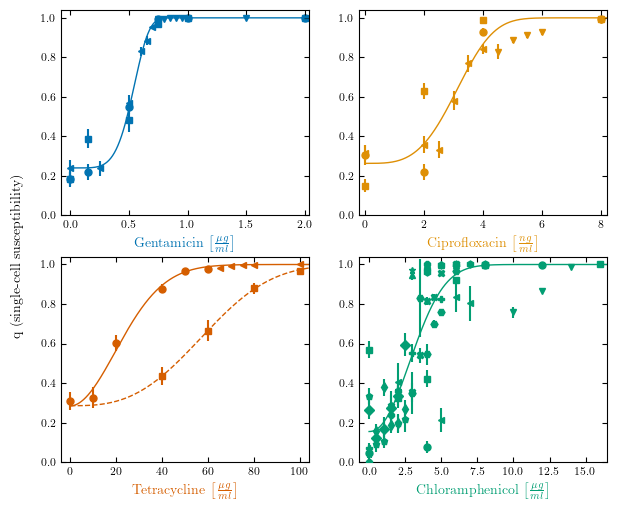

In [9]:
x_fitted = np.linspace(0, 150, 10000)
marker_size=5

fig_label_x_1=-0.17

fig_label_y_1=1

fig, ax = plt.subplots(2,2, figsize=(figWidthInches, figHeightInches))

for i,d in enumerate(Genta.dataset.unique()):
     plot_scatter(Genta[Genta.dataset==d],'q_chip_like',ax[0,0],colors[0],markers[i],marker_size,i,'var_q_chip_like',1)

for i,d in enumerate(Cipro.dataset.unique()):
     plot_scatter(Cipro[Cipro.dataset==d],'q_chip_like',ax[0,1],colors[1],markers[i],marker_size,i,'var_q_chip_like',1)

for i,d in enumerate(Tetra.dataset.unique()):
     plot_scatter(Tetra[Tetra.dataset==d],'q_chip_like',ax[1,0],colors[3],markers[i],marker_size,i,'var_q_chip_like',1)

for i,d in enumerate(Chp.dataset.unique()):
    plot_scatter(Chp[Chp.dataset==d],'q_chip_like',ax[1,1],colors[2],markers[i],marker_size,i,'var_q_chip_like',1)


ax[0,0].plot(x_fitted, 1-(1-Genta_f['q_0'].values[0]) * np.exp(-np.power(x_fitted/Genta_f['a'].values[0],Genta_f['b'].values[0])),color=colors[0],linewidth=lw)

ax[0,1].plot(x_fitted, 1-(1-Cipro_f['q_0'].values[0]) * np.exp(-np.power(x_fitted/Cipro_f['a'].values[0],Cipro_f['b'].values[0])),color=colors[1],linewidth=lw)
ax[1,1].plot(x_fitted, 1-(1-Chp_f['q_0'].values[0]) * np.exp(-np.power(x_fitted/Chp_f['a'].values[0],Chp_f['b'].values[0])),color=colors[2],linewidth=lw)

ax[1,0].plot(x_fitted, 1-(1-Tetra_f['q_0'].values[0]) * np.exp(-np.power(x_fitted/Tetra_f['a'].values[0],Tetra_f['b'].values[0])),color= colors[3],linewidth=lw)
ax[1,0].plot(x_fitted, 1-(1-Tetra_f['q_0'].values[4]) * np.exp(-np.power(x_fitted/Tetra_f['a'].values[4],Tetra_f['b'].values[4])),color= colors[3],linewidth=lw,linestyle='--')


ax[0,0].set_ylabel('')
ax[0,0].set_xlabel(r'Gentamicin $\left[\frac{\mu g}{ml}\right]$',color=(0.00392156862745098, 0.45098039215686275, 0.6980392156862745, 1.0))


ax[0,1].set_ylabel('')
ax[0,1].set_xlabel(r'Ciprofloxacin $\left[\frac{n g}{ml}\right]$',color=colors[1])

ax[1,0].set_ylabel(r'q (single-cell susceptibility)',rotation=90)
ax[1,0].yaxis.set_label_coords(-0.15, 1.0)  # Position at middle of ax[0,0] and ax[1,0]

ax[1,0].set_xlabel(r'Tetracycline $\left[\frac{\mu g}{ml}\right]$',color=colors[3])



ax[1,1].set_ylabel('')
ax[1,1].set_xlabel(r'Chloramphenicol $\left[\frac{\mu g}{ml}\right]$',color=colors[2])



ax[0,0].set_xlim([xmin[0],xmax[0]])
ax[0,0].set_ylim([0,1.04])

ax[0,1].set_xlim([xmin[1],xmax[1]])
ax[0,1].set_ylim([0,1.04])

ax[1,0].set_xlim([xmin[2],xmax[2]])
ax[1,0].set_ylim([0,1.04])

ax[1,1].set_xlim([xmin[3],xmax[3]])
ax[1,1].set_ylim([0,1.04])



# Adjust spacing - hspace controls vertical spacing between rows
plt.subplots_adjust(hspace=0.2)

plt.show()

In [20]:
baseSavePath=''
saveFigPath = os.path.join(baseSavePath,'Figure4.pdf')
fig.savefig(saveFigPath,bbox_inches='tight')